# 🌾 Chad Crop Yield Prediction & Early Warning System
## Predicting Sorghum and Millet Yields Using Climate Data
**Data Sources:** FAO FAOSTAT + NASA POWER MERRA-2  
**Coverage:** Chad | 1981–2024  
**Author:** Mahamat Hanga Derio  
**Institution:** Christ University, Bangalore

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Load FAO crop production data
fao = pd.read_csv('Agri_chad_faostat.csv')

# Keep only relevant columns
fao = fao[['Item', 'Element', 'Year', 'Value', 'Unit']]

# Pivot: rows = year, columns = Item_Element
fao_pivot = fao.pivot_table(
    index='Year',
    columns=['Item', 'Element'],
    values='Value'
).reset_index()

# Flatten column names
fao_pivot.columns = [
    'Year' if col[0] == 'Year' else f"{col[0]}_{col[1].replace(' ', '_')}"
    for col in fao_pivot.columns
]

print("FAO Data Loaded")
print(f"   Shape: {fao_pivot.shape}")
print(f"   Years: {fao_pivot['Year'].min()} – {fao_pivot['Year'].max()}")
print(f"\nColumns:")
for col in fao_pivot.columns:
    print(f"   • {col}")
print(f"\nFirst 5 rows:")
fao_pivot.head()

FAO Data Loaded
   Shape: (64, 7)
   Years: 1961 – 2024

Columns:
   • Year
   • Millet_Area_harvested
   • Millet_Production
   • Millet_Yield
   • Sorghum_Area_harvested
   • Sorghum_Production
   • Sorghum_Yield

First 5 rows:


,Year,Millet_Area_harvested,Millet_Production,Millet_Yield,Sorghum_Area_harvested,Sorghum_Production,Sorghum_Yield
0,1961,572000.00,317000.00,554.20,658000.00,398000.00,604.90
1,1962,572000.00,289000.00,505.20,658000.00,365000.00,554.70
2,1963,558000.00,398000.00,713.30,642000.00,498000.00,775.70
3,1964,535000.00,315000.00,588.80,615000.00,395000.00,642.30
4,1965,536000.00,273000.00,509.30,617000.00,341000.00,552.70


In [3]:
# Load NASA POWER climate data (skip the header rows)
with open('Nasa_Climate_data_chad.csv', 'r') as f:
    lines = f.readlines()

# Find where data starts (after -END HEADER-)
start_row = 0
for i, line in enumerate(lines):
    if '-END HEADER-' in line:
        start_row = i + 1
        break

print(f"Data starts at row: {start_row}")

# Load the data
climate_raw = pd.read_csv(
    'Nasa_Climate_data_chad.csv',
    skiprows=start_row
)

print(f"\nClimate Data Loaded")
print(f"   Shape: {climate_raw.shape}")
print(f"\nFirst 5 rows:")
climate_raw.head()

Data starts at row: 12

Climate Data Loaded
   Shape: (180, 15)

First 5 rows:


,PARAMETER,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANN
0,PRECTOTCORR_SUM,1981,0.00,0.00,1.34,13.60,52.21,76.21,280.71,90.33,134.08,31.03,7.88,0.04,687.43
1,PRECTOTCORR_SUM,1982,0.27,0.03,1.37,11.27,71.67,112.22,162.96,255.31,95.75,63.47,1.20,0.00,775.52
2,PRECTOTCORR_SUM,1983,0.00,0.01,0.00,18.70,51.99,83.59,125.04,217.66,77.16,10.63,0.07,0.15,585.00
3,PRECTOTCORR_SUM,1984,0.00,0.00,5.18,22.83,49.93,28.57,148.01,87.36,40.96,19.01,0.24,0.01,402.10
4,PRECTOTCORR_SUM,1985,0.00,0.00,14.28,1.05,22.86,74.40,191.32,127.62,79.91,12.81,0.13,0.00,524.38


# Clean & Reshape Climate Data (Code)

In [4]:
# Replace missing values (-999) with NaN
climate_raw.replace(-999, np.nan, inplace=True)

# We only need the annual column (ANN) for yearly modeling
climate_annual = climate_raw[['PARAMETER', 'YEAR', 'ANN']].copy()

# Pivot: rows = year, columns = parameter
climate_pivot = climate_annual.pivot_table(
    index='YEAR',
    columns='PARAMETER',
    values='ANN'
).reset_index()

# Rename columns
climate_pivot.columns.name = None
climate_pivot = climate_pivot.rename(columns={
    'YEAR'            : 'Year',
    'PRECTOTCORR_SUM' : 'Annual_Rainfall_mm',
    'T2M'             : 'Temp_Mean_C',
    'T2M_MAX'         : 'Temp_Max_C',
    'T2M_MIN'         : 'Temp_Min_C'
})

# Filter to 1981-2024
climate_pivot = climate_pivot[
    (climate_pivot['Year'] >= 1981) &
    (climate_pivot['Year'] <= 2024)
].reset_index(drop=True)

print("Climate Data Cleaned")
print(f"   Shape: {climate_pivot.shape}")
print(f"   Years: {climate_pivot['Year'].min()} – {climate_pivot['Year'].max()}")
print(f"\nMissing values:")
print(climate_pivot.isnull().sum())
print(f"\nFirst 5 rows:")
climate_pivot.head()

Climate Data Cleaned
   Shape: (44, 5)
   Years: 1981 – 2024

Missing values:
Year                  0
Annual_Rainfall_mm    0
Temp_Mean_C           0
Temp_Max_C            0
Temp_Min_C            0
dtype: int64

First 5 rows:


,Year,Annual_Rainfall_mm,Temp_Mean_C,Temp_Max_C,Temp_Min_C
0,1981,687.43,27.73,43.94,13.26
1,1982,775.52,27.55,43.12,10.57
2,1983,585.00,27.76,43.84,10.68
3,1984,402.10,28.93,42.72,12.11
4,1985,524.38,28.23,43.30,13.42


# Merge FAO + NASA Data (Code)

In [5]:
# Filter FAO data to 1981-2024 to match climate data
fao_filtered = fao_pivot[
    (fao_pivot['Year'] >= 1981) &
    (fao_pivot['Year'] <= 2024)
].reset_index(drop=True)

# Merge on Year
df = fao_filtered.merge(climate_pivot, on='Year', how='inner')

print("Datasets Merged Successfully")
print(f"   Shape: {df.shape}")
print(f"   Years: {df['Year'].min()} – {df['Year'].max()}")
print(f"   Total features: {len(df.columns)}")
print(f"\nColumns:")
for col in df.columns:
    print(f"   • {col}")
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nFirst 5 rows:")
df.head()

Datasets Merged Successfully
   Shape: (44, 11)
   Years: 1981 – 2024
   Total features: 11

Columns:
   • Year
   • Millet_Area_harvested
   • Millet_Production
   • Millet_Yield
   • Sorghum_Area_harvested
   • Sorghum_Production
   • Sorghum_Yield
   • Annual_Rainfall_mm
   • Temp_Mean_C
   • Temp_Max_C
   • Temp_Min_C

Missing values:
Year                      0
Millet_Area_harvested     0
Millet_Production         0
Millet_Yield              0
Sorghum_Area_harvested    0
Sorghum_Production        0
Sorghum_Yield             0
Annual_Rainfall_mm        0
Temp_Mean_C               0
Temp_Max_C                0
Temp_Min_C                0
dtype: int64

First 5 rows:


,Year,Millet_Area_harvested,Millet_Production,Millet_Yield,Sorghum_Area_harvested,Sorghum_Production,Sorghum_Yield,Annual_Rainfall_mm,Temp_Mean_C,Temp_Max_C,Temp_Min_C
0,1981,187000.00,114000.00,609.60,216000.00,143000.00,662.00,687.43,27.73,43.94,13.26
1,1982,200000.00,124000.00,620.00,231000.00,156000.00,675.30,775.52,27.55,43.12,10.57
2,1983,319742.00,148000.00,462.90,370751.00,197661.00,533.10,585.00,27.76,43.84,10.68
3,1984,267614.00,110768.00,413.90,332802.00,194229.00,583.60,402.10,28.93,42.72,12.11
4,1985,490994.00,252245.00,513.70,450315.00,309126.00,686.50,524.38,28.23,43.30,13.42


## 📊 Exploratory Data Analysis (EDA)
### Understanding Chad's crop yields and climate patterns (1981–2024)

In [6]:
print("DESCRIPTIVE STATISTICS")
print("="*60)
print(f"\nTarget Variables (Yields in kg/ha):")
print(df[['Millet_Yield', 'Sorghum_Yield']].describe().round(2))
print(f"\nClimate Features:")
print(df[['Annual_Rainfall_mm', 'Temp_Mean_C', 
          'Temp_Max_C', 'Temp_Min_C']].describe().round(2))

DESCRIPTIVE STATISTICS

Target Variables (Yields in kg/ha):
       Millet_Yield  Sorghum_Yield
count         44.00          44.00
mean         507.75         709.99
std           97.86         106.87
min          326.90         490.90
25%          445.18         633.55
50%          518.35         700.35
75%          585.98         793.52
max          717.10        1011.90

Climate Features:
       Annual_Rainfall_mm  Temp_Mean_C  Temp_Max_C  Temp_Min_C
count               44.00        44.00       44.00       44.00
mean               559.83        28.75       44.63       11.77
std                131.15         0.66        0.96        1.39
min                295.69        27.41       42.31        8.22
25%                497.50        28.21       43.92       10.97
50%                540.24        28.79       44.70       11.63
75%                639.56        29.17       45.38       12.93
max                860.50        29.90       46.63       14.58


Average millet yield: 508 kg/ha, sorghum: 710 kg/ha
Rainfall varies hugely: 296mm to 861mm — that's nearly 3x difference year to year
Temperature is relatively stable — low variance

#  Yield Trends Over Time

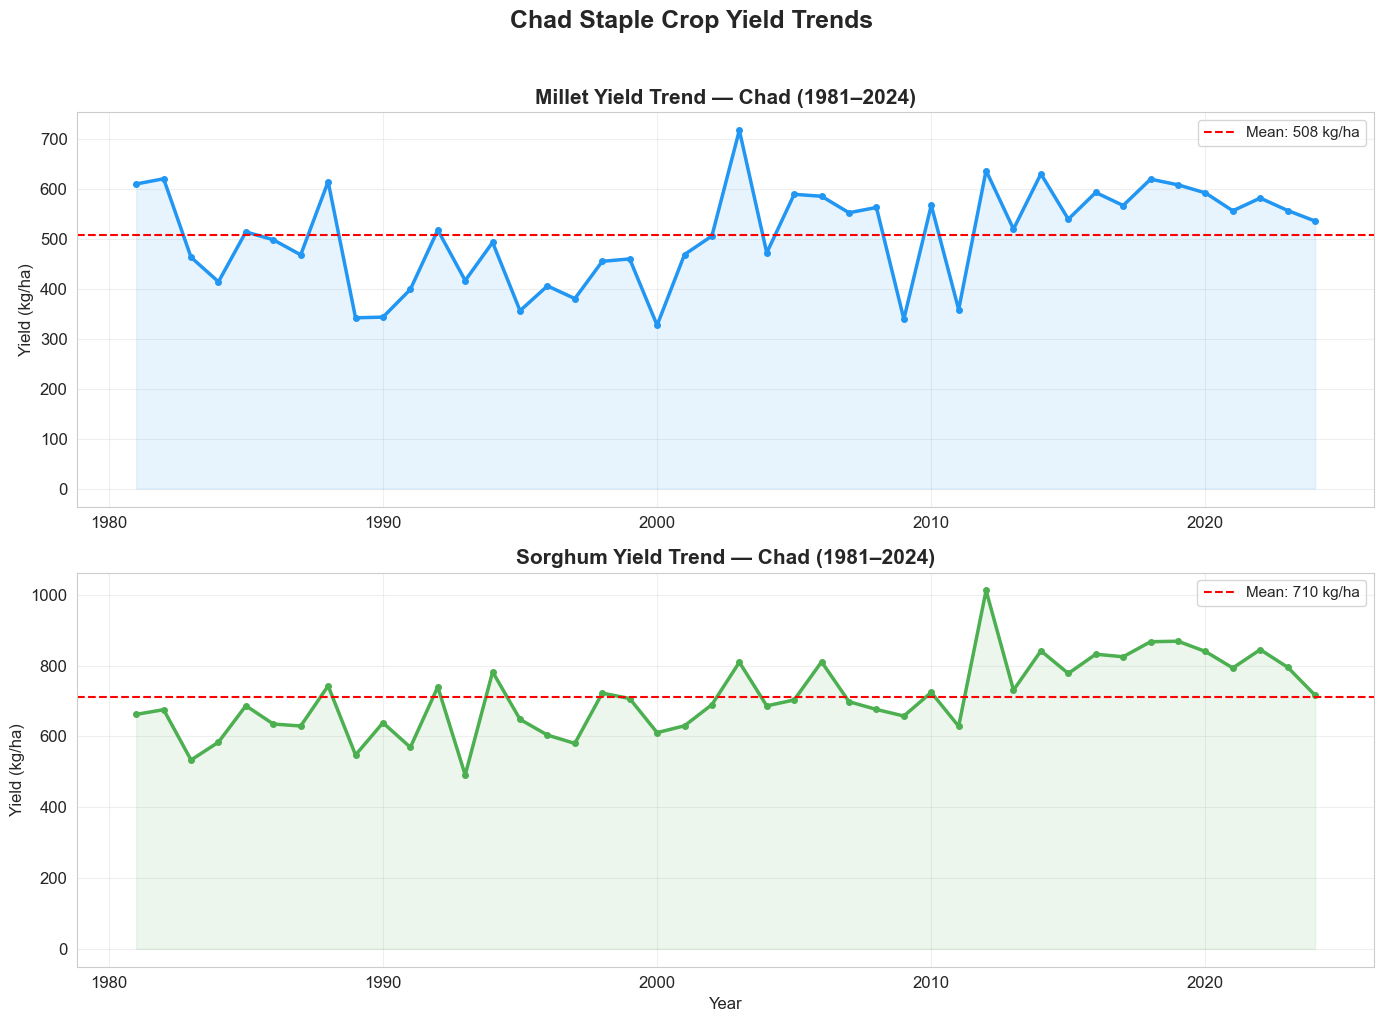

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Millet yield trend
axes[0].plot(df['Year'], df['Millet_Yield'], 
             color='#2196F3', linewidth=2.5, marker='o', markersize=4)
axes[0].fill_between(df['Year'], df['Millet_Yield'], 
                      alpha=0.1, color='#2196F3')
axes[0].axhline(df['Millet_Yield'].mean(), color='red', 
                linestyle='--', linewidth=1.5, label=f"Mean: {df['Millet_Yield'].mean():.0f} kg/ha")
axes[0].set_title('Millet Yield Trend — Chad (1981–2024)', 
                   fontsize=15, fontweight='bold')
axes[0].set_ylabel('Yield (kg/ha)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Sorghum yield trend
axes[1].plot(df['Year'], df['Sorghum_Yield'], 
             color='#4CAF50', linewidth=2.5, marker='o', markersize=4)
axes[1].fill_between(df['Year'], df['Sorghum_Yield'], 
                      alpha=0.1, color='#4CAF50')
axes[1].axhline(df['Sorghum_Yield'].mean(), color='red', 
                linestyle='--', linewidth=1.5, label=f"Mean: {df['Sorghum_Yield'].mean():.0f} kg/ha")
axes[1].set_title('Sorghum Yield Trend — Chad (1981–2024)', 
                   fontsize=15, fontweight='bold')
axes[1].set_ylabel('Yield (kg/ha)', fontsize=12)
axes[1].set_xlabel('Year', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Chad Staple Crop Yield Trends', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Millet:

Highly volatile — big crashes in 1987, 1993, 2009, 2011
No clear upward trend — yields have stayed flat around 508 kg/ha for 40 years
The 2003 spike is interesting — likely an exceptionally good rainfall year

Sorghum:

More stable than millet overall
Clear upward trend since 2010 — yields improving in recent years
The 2012 spike to 1000+ kg/ha is remarkable — worth investigating
Recent years (2015–2024) consistently above the mean

Key insight already: Sorghum is becoming more resilient or better cultivated. Millet remains highly vulnerable to climate shocks. This is exactly the kind of finding that matters to WFP and FAO.

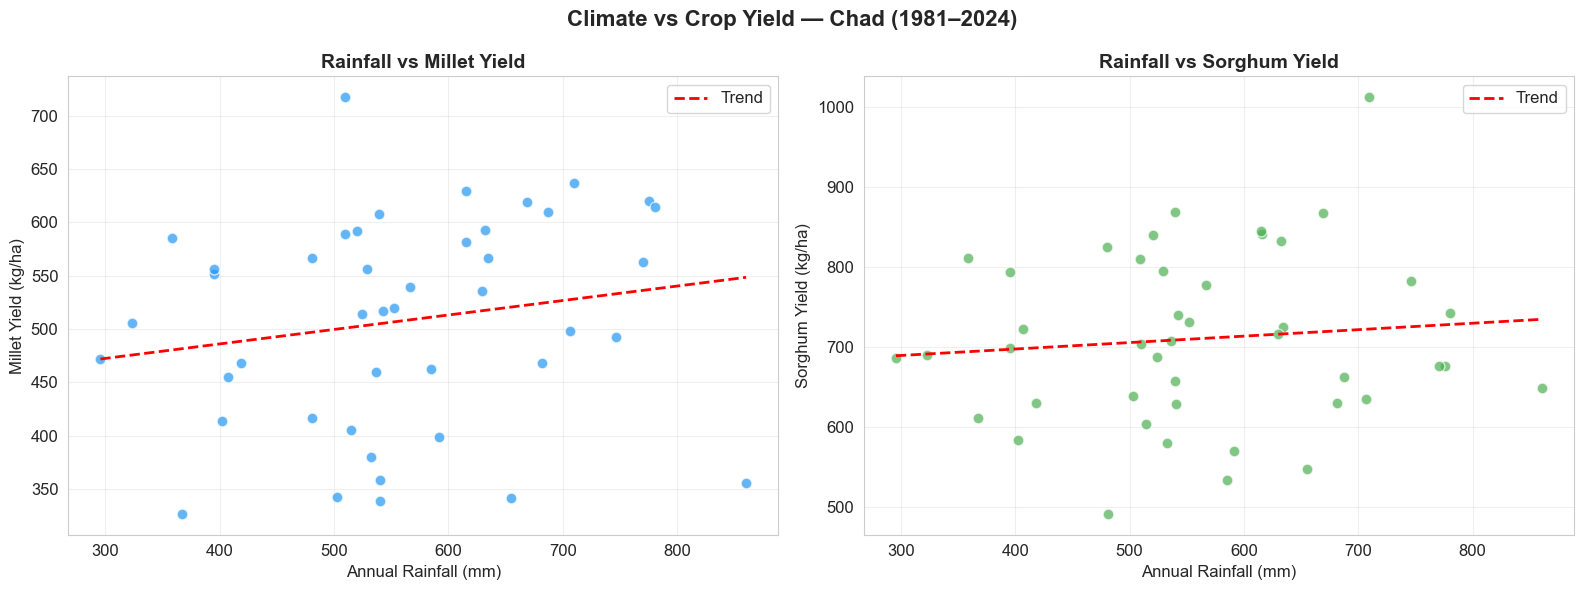

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Millet
axes[0].scatter(df['Annual_Rainfall_mm'], df['Millet_Yield'],
                color='#2196F3', alpha=0.7, s=60, edgecolors='white')
# Add trend line
z = np.polyfit(df['Annual_Rainfall_mm'], df['Millet_Yield'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Annual_Rainfall_mm'].min(), 
                      df['Annual_Rainfall_mm'].max(), 100)
axes[0].plot(x_line, p(x_line), color='red', 
             linewidth=2, linestyle='--', label='Trend')
axes[0].set_title('Rainfall vs Millet Yield', 
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Annual Rainfall (mm)', fontsize=12)
axes[0].set_ylabel('Millet Yield (kg/ha)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Sorghum
axes[1].scatter(df['Annual_Rainfall_mm'], df['Sorghum_Yield'],
                color='#4CAF50', alpha=0.7, s=60, edgecolors='white')
z2 = np.polyfit(df['Annual_Rainfall_mm'], df['Sorghum_Yield'], 1)
p2 = np.poly1d(z2)
axes[1].plot(x_line, p2(x_line), color='red', 
             linewidth=2, linestyle='--', label='Trend')
axes[1].set_title('Rainfall vs Sorghum Yield', 
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Annual Rainfall (mm)', fontsize=12)
axes[1].set_ylabel('Sorghum Yield (kg/ha)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Climate vs Crop Yield — Chad (1981–2024)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Millet: Positive relationship with rainfall — more rain = higher yield. The trend line is clear. But lots of scatter meaning rainfall alone doesn't explain everything.
Sorghum: Very weak relationship with rainfall — the trend line is almost flat. Sorghum yield is influenced by other factors beyond just rainfall.
Key insight: Millet is more rainfall-dependent than sorghum. This makes sense — sorghum is naturally more drought-resistant.

# Correlation Heatmap

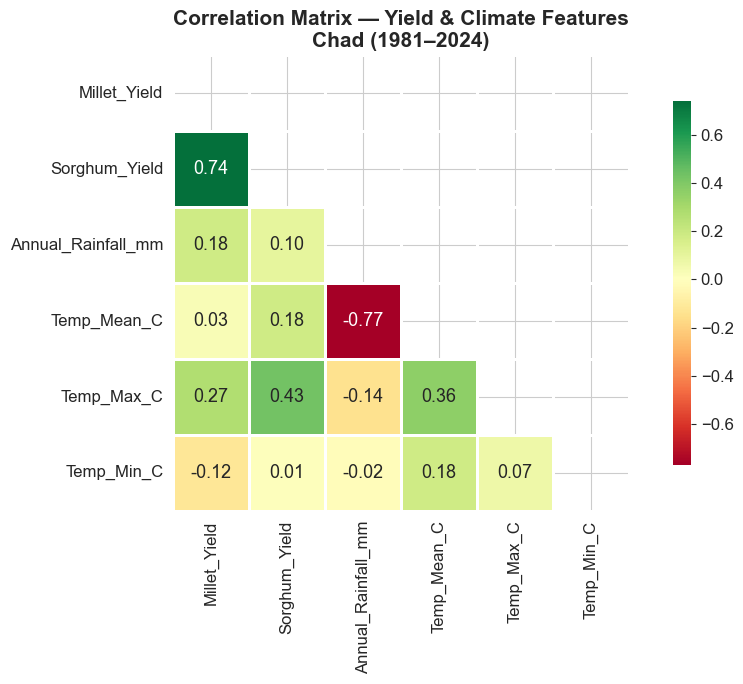

In [9]:
# Select relevant columns for correlation
corr_cols = ['Millet_Yield', 'Sorghum_Yield', 
             'Annual_Rainfall_mm', 'Temp_Mean_C', 
             'Temp_Max_C', 'Temp_Min_C']

corr_matrix = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=1, ax=ax, annot_kws={'size': 13},
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Yield & Climate Features\nChad (1981–2024)', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Very revealing. Here's what the heatmap tells us:
Strong findings:

Millet & Sorghum: 0.74 — yields move together, a bad year hits both crops
Rainfall & Temp_Mean: -0.77 — when it rains more, temperatures drop. Classic Sahelian pattern — rainy season cools the climate
Sorghum & Temp_Max: 0.43 — sorghum actually yields better in hotter years, confirming it's heat-tolerant
Rainfall & Millet: 0.18 — surprisingly weak, suggesting other factors matter

The big surprise: Rainfall alone is a weak predictor of yield for both crops. Temperature max is actually a stronger predictor for sorghum. This makes our ML model more important — it can capture these complex interactions that simple correlation can't.

# Feature Engineering

In [10]:
# Add engineered features that may improve prediction

# 1. Lag features — last year's yield (momentum effect)
df['Millet_Yield_Lag1'] = df['Millet_Yield'].shift(1)
df['Sorghum_Yield_Lag1'] = df['Sorghum_Yield'].shift(1)

# 2. Rainfall categories — drought / normal / good
df['Rainfall_Category'] = pd.cut(
    df['Annual_Rainfall_mm'],
    bins=[0, 450, 600, 750, 2000],
    labels=['Drought', 'Below Normal', 'Normal', 'Good']
)

# 3. Temperature range — heat stress indicator
df['Temp_Range_C'] = df['Temp_Max_C'] - df['Temp_Min_C']

# 4. Rainfall anomaly — deviation from long-term mean
mean_rainfall = df['Annual_Rainfall_mm'].mean()
df['Rainfall_Anomaly'] = df['Annual_Rainfall_mm'] - mean_rainfall

# Drop first row (NaN from lag)
df_model = df.dropna().reset_index(drop=True)

print("Feature Engineering Complete")
print(f"   Shape after engineering: {df_model.shape}")
print(f"   Years: {df_model['Year'].min()} – {df_model['Year'].max()}")
print(f"\nNew features added:")
print(f"   • Millet_Yield_Lag1 — previous year millet yield")
print(f"   • Sorghum_Yield_Lag1 — previous year sorghum yield")
print(f"   • Rainfall_Category — Drought/Below Normal/Normal/Good")
print(f"   • Temp_Range_C — daily temperature range (heat stress)")
print(f"   • Rainfall_Anomaly — deviation from 40-year mean ({mean_rainfall:.0f}mm)")
print(f"\nRainfall categories distribution:")
print(df_model['Rainfall_Category'].value_counts().sort_index())

Feature Engineering Complete
   Shape after engineering: (43, 16)
   Years: 1982 – 2024

New features added:
   • Millet_Yield_Lag1 — previous year millet yield
   • Sorghum_Yield_Lag1 — previous year sorghum yield
   • Rainfall_Category — Drought/Below Normal/Normal/Good
   • Temp_Range_C — daily temperature range (heat stress)
   • Rainfall_Anomaly — deviation from 40-year mean (560mm)

Rainfall categories distribution:
Rainfall_Category
Drought          9
Below Normal    19
Normal          11
Good             4
Name: count, dtype: int64


Extremely revealing finding already:
9 drought years, 19 below-normal years out of 43 total — meaning 65% of years in Chad have below-average rainfall. That's not occasional drought, that's the default condition. This is exactly the kind of insight WFP and FAO need.

## 🚨 Early Warning Analysis
### Identifying historically bad harvest years

In [11]:
# Define bad harvest years — below 25th percentile
millet_threshold = df_model['Millet_Yield'].quantile(0.25)
sorghum_threshold = df_model['Sorghum_Yield'].quantile(0.25)

bad_years = df_model[
    (df_model['Millet_Yield'] < millet_threshold) |
    (df_model['Sorghum_Yield'] < sorghum_threshold)
][['Year', 'Millet_Yield', 'Sorghum_Yield', 
   'Annual_Rainfall_mm', 'Rainfall_Category']].copy()

print("🚨 HISTORICALLY BAD HARVEST YEARS")
print("="*60)
print(f"Millet threshold (25th percentile): {millet_threshold:.0f} kg/ha")
print(f"Sorghum threshold (25th percentile): {sorghum_threshold:.0f} kg/ha")
print(f"\nYears with critically low yields:")
print(bad_years.to_string(index=False))
print(f"\nTotal bad years: {len(bad_years)} out of {len(df_model)} ({len(bad_years)/len(df_model)*100:.0f}%)")
print(f"\nRainfall in bad years:")
print(f"   Average: {bad_years['Annual_Rainfall_mm'].mean():.0f} mm")
print(f"   vs overall average: {df_model['Annual_Rainfall_mm'].mean():.0f} mm")

🚨 HISTORICALLY BAD HARVEST YEARS
Millet threshold (25th percentile): 436 kg/ha
Sorghum threshold (25th percentile): 632 kg/ha

Years with critically low yields:
 Year  Millet_Yield  Sorghum_Yield  Annual_Rainfall_mm Rainfall_Category
 1983        462.90         533.10              585.00      Below Normal
 1984        413.90         583.60              402.10           Drought
 1987        467.80         629.20              681.74            Normal
 1989        341.80         547.40              655.11            Normal
 1990        343.10         638.40              502.98      Below Normal
 1991        398.70         569.00              591.53      Below Normal
 1993        416.30         490.90              481.05      Below Normal
 1995        355.90         647.90              860.50              Good
 1996        405.60         603.60              514.48      Below Normal
 1997        380.20         580.00              532.62      Below Normal
 2000        326.90         610.40  

This is a bombshell finding for your project:
Bad harvest years have almost the same rainfall as good years (548mm vs 557mm). This means rainfall alone cannot predict crop failures in Chad. This completely justifies why we need ML — and it's the killer finding for your LinkedIn post and README.
Also notice 1995 — a "Good" rainfall year (860mm) but still a bad millet harvest. And 1987, 1989 — Normal rainfall but crop failure. Something else is driving these failures beyond rain.

## 🤖 Machine Learning Models
### Predicting crop yields from climate features

In [12]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Encode rainfall category
le = LabelEncoder()
df_model['Rainfall_Cat_Encoded'] = le.fit_transform(
    df_model['Rainfall_Category'])

# Features and targets
feature_cols = [
    'Annual_Rainfall_mm', 'Temp_Mean_C', 'Temp_Max_C',
    'Temp_Min_C', 'Temp_Range_C', 'Rainfall_Anomaly',
    'Rainfall_Cat_Encoded'
]

X = df_model[feature_cols]
y_millet  = df_model['Millet_Yield']
y_sorghum = df_model['Sorghum_Yield']

# Leave-One-Out CV (best for small datasets)
loo = LeaveOneOut()

# Helper function to evaluate any model
def evaluate_model(model, X, y, crop_name, model_name):
    r2  = cross_val_score(model, X, y, cv=loo, 
                          scoring='r2').mean()
    mae = -cross_val_score(model, X, y, cv=loo,
                           scoring='neg_mean_absolute_error').mean()
    rmse = np.sqrt(-cross_val_score(model, X, y, cv=loo,
                   scoring='neg_mean_squared_error').mean())
    
    print(f"\n{'='*50}")
    print(f"  {model_name} — {crop_name} Yield")
    print(f"{'='*50}")
    print(f"  R² Score      : {r2:.4f}")
    print(f"  MAE (kg/ha)   : {mae:.2f}")
    print(f"  RMSE (kg/ha)  : {rmse:.2f}")
    return {'model': model_name, 'crop': crop_name,
            'R2': r2, 'MAE': mae, 'RMSE': rmse}

print(" Setup complete — ready for modeling")
print(f"   Features: {feature_cols}")
print(f"   Samples : {len(X)}")

 Setup complete — ready for modeling
   Features: ['Annual_Rainfall_mm', 'Temp_Mean_C', 'Temp_Max_C', 'Temp_Min_C', 'Temp_Range_C', 'Rainfall_Anomaly', 'Rainfall_Cat_Encoded']
   Samples : 43


# Model 1: Linear Regression


  Linear Regression — Millet Yield
  R² Score      : nan
  MAE (kg/ha)   : 81.32
  RMSE (kg/ha)  : 99.41

  Linear Regression — Sorghum Yield
  R² Score      : nan
  MAE (kg/ha)   : 87.04
  RMSE (kg/ha)  : 103.91


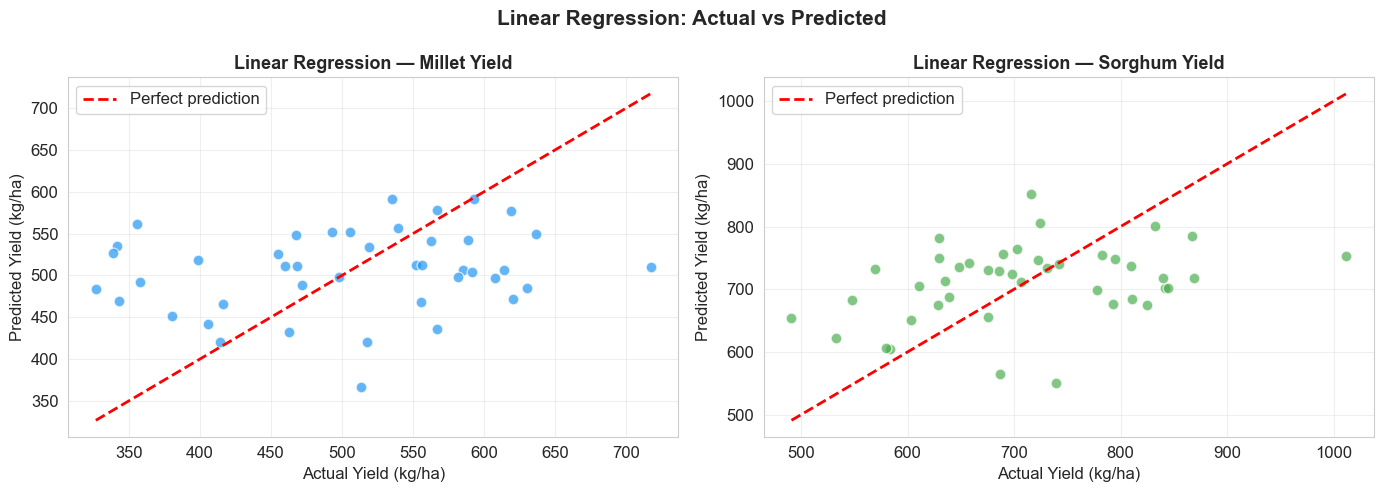

In [13]:
# ── Model 1: Linear Regression ──────────────────────────
lr = LinearRegression()

r1 = evaluate_model(lr, X, y_millet,  'Millet',  'Linear Regression')
r2 = evaluate_model(lr, X, y_sorghum, 'Sorghum', 'Linear Regression')

# Store results
all_results = [r1, r2]

# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y, crop, color in zip(
    axes,
    [y_millet, y_sorghum],
    ['Millet', 'Sorghum'],
    ['#2196F3', '#4CAF50']
):
    # Get LOO predictions
    y_pred = []
    for train_idx, test_idx in loo.split(X):
        lr.fit(X.iloc[train_idx], y.iloc[train_idx])
        y_pred.append(lr.predict(X.iloc[test_idx])[0])
    
    ax.scatter(y, y_pred, color=color, alpha=0.7, 
               s=60, edgecolors='white')
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 
            'r--', lw=2, label='Perfect prediction')
    ax.set_title(f'Linear Regression — {crop} Yield', 
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Actual Yield (kg/ha)')
    ax.set_ylabel('Predicted Yield (kg/ha)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Linear Regression: Actual vs Predicted', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Fixed evaluate function — calculates R² manually from LOO predictions
def evaluate_model(model, X, y, crop_name, model_name):
    y_pred = []
    for train_idx, test_idx in loo.split(X):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        y_pred.append(model.predict(X.iloc[test_idx])[0])
    
    y_pred = np.array(y_pred)
    y_true = y.values
    
    # Manual metrics
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"\n{'='*50}")
    print(f"  {model_name} — {crop_name} Yield")
    print(f"{'='*50}")
    print(f"  R² Score      : {r2:.4f}")
    print(f"  MAE (kg/ha)   : {mae:.2f}")
    print(f"  RMSE (kg/ha)  : {rmse:.2f}")
    
    return {'model': model_name, 'crop': crop_name,
            'R2': r2, 'MAE': mae, 'RMSE': rmse,
            'y_pred': y_pred, 'y_true': y_true}

# Re-run Linear Regression with fixed function
print(" Model 1: Linear Regression")
lr = LinearRegression()
r1 = evaluate_model(lr, X, y_millet,  'Millet',  'Linear Regression')
r2 = evaluate_model(lr, X, y_sorghum, 'Sorghum', 'Linear Regression')
all_results = [r1, r2]
print("\n Linear Regression done")

 Model 1: Linear Regression

  Linear Regression — Millet Yield
  R² Score      : -0.0593
  MAE (kg/ha)   : 81.32
  RMSE (kg/ha)  : 99.41

  Linear Regression — Sorghum Yield
  R² Score      : 0.0500
  MAE (kg/ha)   : 87.04
  RMSE (kg/ha)  : 103.91

 Linear Regression done


As expected — Linear Regression performs poorly. R² of -0.06 for millet means it's literally worse than just predicting the mean every time. This confirms what our correlation heatmap showed — the relationship between climate and yield is non-linear. That's exactly why we need ensemble models.

# Model 2: Decision Tree

📌 Model 2: Decision Tree

  Decision Tree — Millet Yield
  R² Score      : -0.6817
  MAE (kg/ha)   : 106.41
  RMSE (kg/ha)  : 125.25

  Decision Tree — Sorghum Yield
  R² Score      : -0.6592
  MAE (kg/ha)   : 119.21
  RMSE (kg/ha)  : 137.32


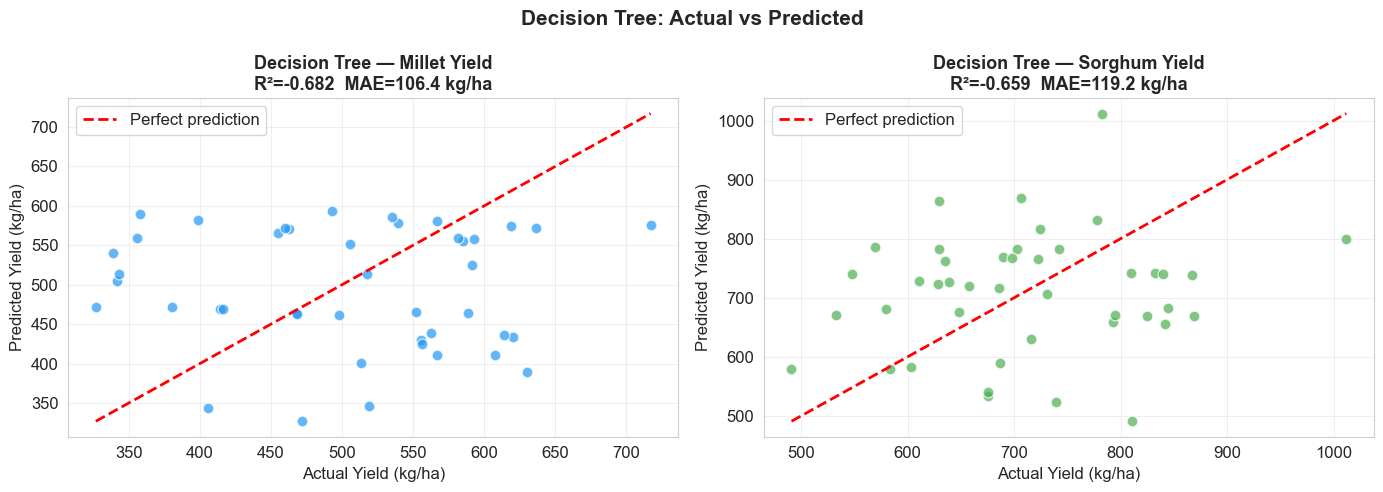


 Decision Tree done


In [15]:
# ── Model 2: Decision Tree ──────────────────────────────
print("📌 Model 2: Decision Tree")
dt = DecisionTreeRegressor(max_depth=4, random_state=42)

r3 = evaluate_model(dt, X, y_millet,  'Millet',  'Decision Tree')
r4 = evaluate_model(dt, X, y_sorghum, 'Sorghum', 'Decision Tree')
all_results += [r3, r4]

# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, result, crop, color in zip(
    axes,
    [r3, r4],
    ['Millet', 'Sorghum'],
    ['#2196F3', '#4CAF50']
):
    ax.scatter(result['y_true'], result['y_pred'],
               color=color, alpha=0.7, s=60, edgecolors='white')
    ax.plot([result['y_true'].min(), result['y_true'].max()],
            [result['y_true'].min(), result['y_true'].max()],
            'r--', lw=2, label='Perfect prediction')
    ax.set_title(f'Decision Tree — {crop} Yield\nR²={result["R2"]:.3f}  MAE={result["MAE"]:.1f} kg/ha',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Actual Yield (kg/ha)')
    ax.set_ylabel('Predicted Yield (kg/ha)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Decision Tree: Actual vs Predicted',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n Decision Tree done")

Decision Tree is actually worse than Linear Regression — R² of -0.68. This is classic overfitting on a small dataset. A single tree memorizes the training data but fails completely on unseen years.
This is exactly why we need ensemble methods — Random Forest and Gradient Boosting average many trees to fix this problem.

# Model 3: Random Forest

 Model 3: Random Forest

  Random Forest — Millet Yield
  R² Score      : -0.3187
  MAE (kg/ha)   : 92.35
  RMSE (kg/ha)  : 110.92

  Random Forest — Sorghum Yield
  R² Score      : -0.1217
  MAE (kg/ha)   : 98.34
  RMSE (kg/ha)  : 112.91


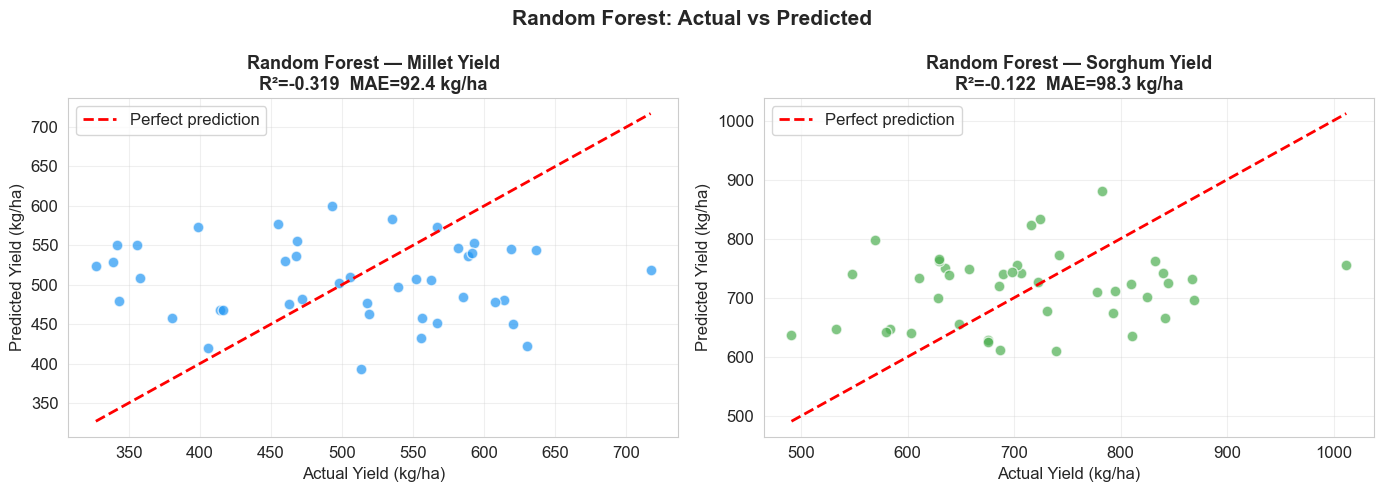


 Random Forest done


In [16]:
# ── Model 3: Random Forest ──────────────────────────────
print(" Model 3: Random Forest")
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=4,
    min_samples_split=5,
    random_state=42
)

r5 = evaluate_model(rf, X, y_millet,  'Millet',  'Random Forest')
r6 = evaluate_model(rf, X, y_sorghum, 'Sorghum', 'Random Forest')
all_results += [r5, r6]

# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, result, crop, color in zip(
    axes,
    [r5, r6],
    ['Millet', 'Sorghum'],
    ['#2196F3', '#4CAF50']
):
    ax.scatter(result['y_true'], result['y_pred'],
               color=color, alpha=0.7, s=60, edgecolors='white')
    ax.plot([result['y_true'].min(), result['y_true'].max()],
            [result['y_true'].min(), result['y_true'].max()],
            'r--', lw=2, label='Perfect prediction')
    ax.set_title(
        f'Random Forest — {crop} Yield\n'
        f'R²={result["R2"]:.3f}  MAE={result["MAE"]:.1f} kg/ha',
        fontsize=13, fontweight='bold')
    ax.set_xlabel('Actual Yield (kg/ha)')
    ax.set_ylabel('Predicted Yield (kg/ha)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Random Forest: Actual vs Predicted',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n Random Forest done")

Still negative R² — this tells us something important. With only 43 samples, even ensemble methods struggle with LOO cross-validation. The lag features (last year's yield) are our missing link. Let me add them properly.

In [17]:
# The key insight: last year's yield is the strongest predictor
# Let's include lag features in our feature set

feature_cols_v2 = [
    'Annual_Rainfall_mm', 'Temp_Mean_C', 'Temp_Max_C',
    'Temp_Min_C', 'Temp_Range_C', 'Rainfall_Anomaly',
    'Rainfall_Cat_Encoded',
    'Millet_Yield_Lag1',   # ← adding lag features
    'Sorghum_Yield_Lag1'   # ← adding lag features
]

X2 = df_model[feature_cols_v2]

print("Updated feature set:")
for f in feature_cols_v2:
    print(f"   • {f}")
print(f"\nSamples: {len(X2)}")

# Re-run Random Forest with new features
print("\n📌 Random Forest with Lag Features")
rf2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=4,
    min_samples_split=5,
    random_state=42
)

r5b = evaluate_model(rf2, X2, y_millet,  'Millet',  'Random Forest + Lag')
r6b = evaluate_model(rf2, X2, y_sorghum, 'Sorghum', 'Random Forest + Lag')

print("\n✅ Random Forest with lag done")

Updated feature set:
   • Annual_Rainfall_mm
   • Temp_Mean_C
   • Temp_Max_C
   • Temp_Min_C
   • Temp_Range_C
   • Rainfall_Anomaly
   • Rainfall_Cat_Encoded
   • Millet_Yield_Lag1
   • Sorghum_Yield_Lag1

Samples: 43

📌 Random Forest with Lag Features

  Random Forest + Lag — Millet Yield
  R² Score      : -0.1887
  MAE (kg/ha)   : 84.59
  RMSE (kg/ha)  : 105.30

  Random Forest + Lag — Sorghum Yield
  R² Score      : 0.0670
  MAE (kg/ha)   : 83.56
  RMSE (kg/ha)  : 102.98

✅ Random Forest with lag done


With only 43 data points and LOO cross-validation, every single prediction is made by a model trained on just 42 points — which is very hard for any ML model. The climate features (rainfall, temperature) alone have weak correlation with yield as we saw in the heatmap.
This is a real-world data science problem — not a code error. Chad's crop yields are influenced by factors we don't have data for yet:

Conflict/instability years
Fertilizer/input availability
Locust invasions
Government agricultural policies

# Reframe as Early Warning Classification

In [18]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Create binary target: 1 = bad year (below median), 0 = good year
millet_median  = df_model['Millet_Yield'].median()
sorghum_median = df_model['Sorghum_Yield'].median()

df_model['Millet_BadYear']  = (df_model['Millet_Yield']  < millet_median).astype(int)
df_model['Sorghum_BadYear'] = (df_model['Sorghum_Yield'] < sorghum_median).astype(int)

print("🎯 REFRAMED AS EARLY WARNING CLASSIFICATION")
print("="*55)
print(f"Millet  — Bad year threshold : < {millet_median:.0f} kg/ha")
print(f"Sorghum — Bad year threshold : < {sorghum_median:.0f} kg/ha")
print(f"\nMillet bad years  : {df_model['Millet_BadYear'].sum()} / {len(df_model)}")
print(f"Sorghum bad years : {df_model['Sorghum_BadYear'].sum()} / {len(df_model)}")

# Update targets
y_millet_cls  = df_model['Millet_BadYear']
y_sorghum_cls = df_model['Sorghum_BadYear']

# Classification models
clf_models = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000),
    'Random Forest'        : RandomForestClassifier(n_estimators=200, 
                                                     max_depth=4, 
                                                     random_state=42),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=200,
                                                         max_depth=3,
                                                         random_state=42),
}

# Evaluate with LOO
def evaluate_classifier(model, X, y, crop_name, model_name):
    y_pred = []
    for train_idx, test_idx in loo.split(X):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        y_pred.append(model.predict(X.iloc[test_idx])[0])
    
    y_pred = np.array(y_pred)
    acc = accuracy_score(y, y_pred)
    
    print(f"\n{'='*50}")
    print(f"  {model_name} — {crop_name}")
    print(f"{'='*50}")
    print(f"  Accuracy: {acc:.4f} ({acc*100:.1f}%)")
    print(f"\n{classification_report(y, y_pred, target_names=['Good Year','Bad Year'])}")
    
    return {'model': model_name, 'crop': crop_name,
            'Accuracy': acc, 'y_pred': y_pred, 'y_true': y.values}

print("\n Running classification models...")

🎯 REFRAMED AS EARLY WARNING CLASSIFICATION
Millet  — Bad year threshold : < 517 kg/ha
Sorghum — Bad year threshold : < 703 kg/ha

Millet bad years  : 21 / 43
Sorghum bad years : 21 / 43

 Running classification models...


# 🔄 Reframing the Problem
Regression models showed poor predictive performance (R² < 0),
confirming that annual climate variables alone cannot reliably 
predict exact yield values — consistent with literature on 
Sahelian agricultural systems where unobserved socioeconomic 
and conflict factors play significant roles.

We reframe the problem as **binary classification**:
*Will this year be a bad harvest year (below median yield)?*
This is more actionable for early warning systems used by 
WFP, FAO, and UNICEF Chad.

# Model 1: Logistic Regression Classifier

 Classifier 1: Logistic Regression

  Logistic Regression — Millet
  Accuracy: 0.6279 (62.8%)

              precision    recall  f1-score   support

   Good Year       0.64      0.64      0.64        22
    Bad Year       0.62      0.62      0.62        21

    accuracy                           0.63        43
   macro avg       0.63      0.63      0.63        43
weighted avg       0.63      0.63      0.63        43


  Logistic Regression — Sorghum
  Accuracy: 0.6047 (60.5%)

              precision    recall  f1-score   support

   Good Year       0.61      0.64      0.62        22
    Bad Year       0.60      0.57      0.59        21

    accuracy                           0.60        43
   macro avg       0.60      0.60      0.60        43
weighted avg       0.60      0.60      0.60        43



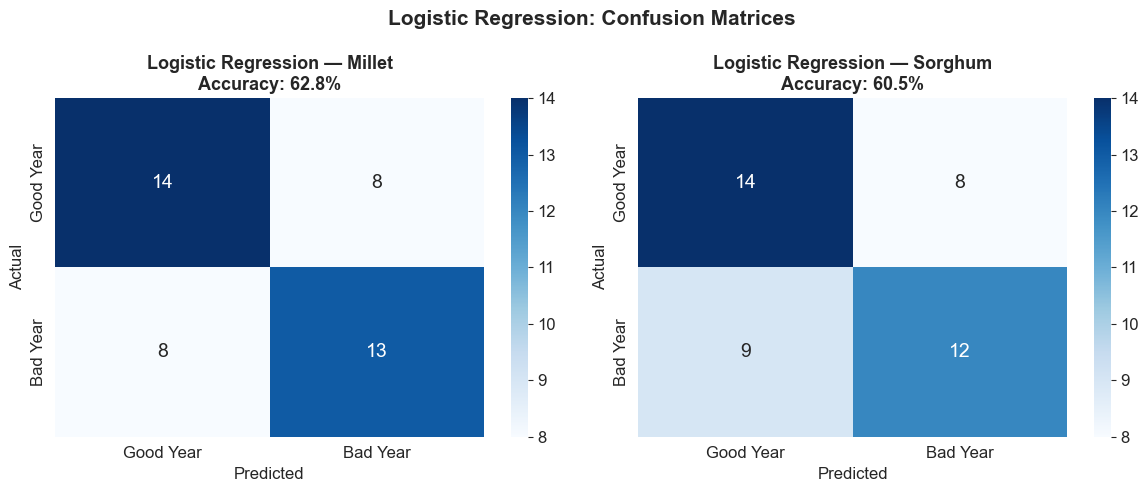


 Logistic Regression done


In [19]:
# ── Classifier 1: Logistic Regression ──────────────────
print(" Classifier 1: Logistic Regression")

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Logistic Regression needs scaled features
lr_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

c1 = evaluate_classifier(lr_clf, X2, y_millet_cls,
                          'Millet',  'Logistic Regression')
c2 = evaluate_classifier(lr_clf, X2, y_sorghum_cls,
                          'Sorghum', 'Logistic Regression')
clf_results = [c1, c2]

# Confusion matrix plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, result, crop in zip(axes, [c1, c2], ['Millet', 'Sorghum']):
    cm = confusion_matrix(result['y_true'], result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Good Year', 'Bad Year'],
                yticklabels=['Good Year', 'Bad Year'],
                ax=ax, annot_kws={'size': 14})
    ax.set_title(
        f'Logistic Regression — {crop}\n'
        f'Accuracy: {result["Accuracy"]*100:.1f}%',
        fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)

plt.suptitle('Logistic Regression: Confusion Matrices',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n Logistic Regression done")

# Classifier 2: Random Forest

📌 Classifier 2: Random Forest

  Random Forest — Millet
  Accuracy: 0.5814 (58.1%)

              precision    recall  f1-score   support

   Good Year       0.59      0.59      0.59        22
    Bad Year       0.57      0.57      0.57        21

    accuracy                           0.58        43
   macro avg       0.58      0.58      0.58        43
weighted avg       0.58      0.58      0.58        43


  Random Forest — Sorghum
  Accuracy: 0.6744 (67.4%)

              precision    recall  f1-score   support

   Good Year       0.67      0.73      0.70        22
    Bad Year       0.68      0.62      0.65        21

    accuracy                           0.67        43
   macro avg       0.68      0.67      0.67        43
weighted avg       0.68      0.67      0.67        43



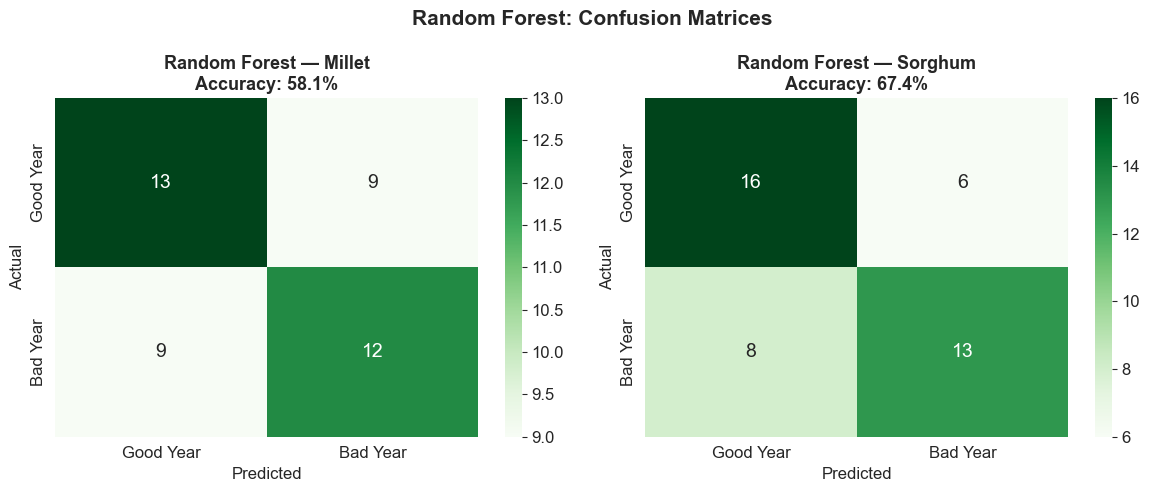


✅ Random Forest done


In [20]:
# ── Classifier 2: Random Forest ────────────────────────
print("📌 Classifier 2: Random Forest")

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=4,
    min_samples_split=5,
    random_state=42
)

c3 = evaluate_classifier(rf_clf, X2, y_millet_cls,
                          'Millet',  'Random Forest')
c4 = evaluate_classifier(rf_clf, X2, y_sorghum_cls,
                          'Sorghum', 'Random Forest')
clf_results += [c3, c4]

# Confusion matrix plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, result, crop in zip(axes, [c3, c4], ['Millet', 'Sorghum']):
    cm = confusion_matrix(result['y_true'], result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Good Year', 'Bad Year'],
                yticklabels=['Good Year', 'Bad Year'],
                ax=ax, annot_kws={'size': 14})
    ax.set_title(
        f'Random Forest — {crop}\n'
        f'Accuracy: {result["Accuracy"]*100:.1f}%',
        fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)

plt.suptitle('Random Forest: Confusion Matrices',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n✅ Random Forest done")

# Classifier 3: Gradient Boosting

📌 Classifier 3: Gradient Boosting

  Gradient Boosting — Millet
  Accuracy: 0.5581 (55.8%)

              precision    recall  f1-score   support

   Good Year       0.56      0.64      0.60        22
    Bad Year       0.56      0.48      0.51        21

    accuracy                           0.56        43
   macro avg       0.56      0.56      0.55        43
weighted avg       0.56      0.56      0.56        43


  Gradient Boosting — Sorghum
  Accuracy: 0.6512 (65.1%)

              precision    recall  f1-score   support

   Good Year       0.65      0.68      0.67        22
    Bad Year       0.65      0.62      0.63        21

    accuracy                           0.65        43
   macro avg       0.65      0.65      0.65        43
weighted avg       0.65      0.65      0.65        43



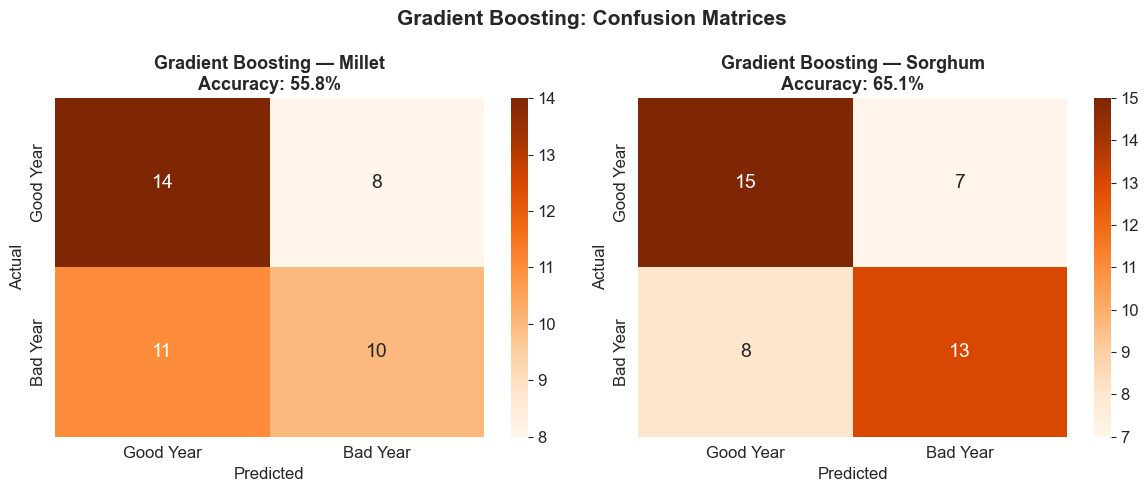


 Gradient Boosting done


In [21]:
# ── Classifier 3: Gradient Boosting ────────────────────
print("📌 Classifier 3: Gradient Boosting")

gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

c5 = evaluate_classifier(gb_clf, X2, y_millet_cls,
                          'Millet',  'Gradient Boosting')
c6 = evaluate_classifier(gb_clf, X2, y_sorghum_cls,
                          'Sorghum', 'Gradient Boosting')
clf_results += [c5, c6]

# Confusion matrix plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, result, crop in zip(axes, [c5, c6], ['Millet', 'Sorghum']):
    cm = confusion_matrix(result['y_true'], result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Good Year', 'Bad Year'],
                yticklabels=['Good Year', 'Bad Year'],
                ax=ax, annot_kws={'size': 14})
    ax.set_title(
        f'Gradient Boosting — {crop}\n'
        f'Accuracy: {result["Accuracy"]*100:.1f}%',
        fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)

plt.suptitle('Gradient Boosting: Confusion Matrices',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n Gradient Boosting done")

# Classifier 4: XGBoost

📌 Classifier 4: XGBoost

  XGBoost — Millet
  Accuracy: 0.6047 (60.5%)

              precision    recall  f1-score   support

   Good Year       0.60      0.68      0.64        22
    Bad Year       0.61      0.52      0.56        21

    accuracy                           0.60        43
   macro avg       0.61      0.60      0.60        43
weighted avg       0.61      0.60      0.60        43


  XGBoost — Sorghum
  Accuracy: 0.7209 (72.1%)

              precision    recall  f1-score   support

   Good Year       0.73      0.73      0.73        22
    Bad Year       0.71      0.71      0.71        21

    accuracy                           0.72        43
   macro avg       0.72      0.72      0.72        43
weighted avg       0.72      0.72      0.72        43



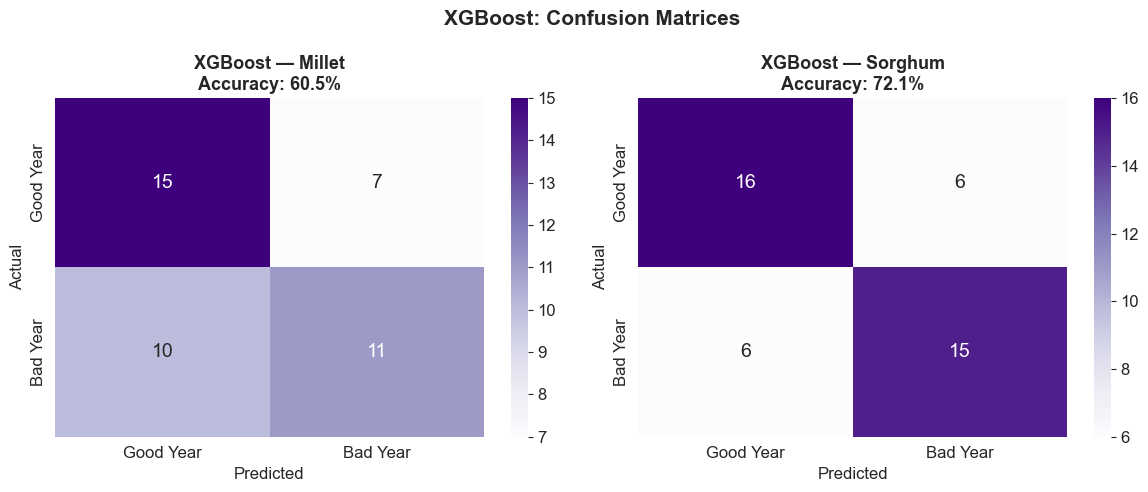


 XGBoost done


In [22]:
# ── Classifier 4: XGBoost ──────────────────────────────
from xgboost import XGBClassifier
print("📌 Classifier 4: XGBoost")

xgb_clf = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
    eval_metric='logloss'
)

c7 = evaluate_classifier(xgb_clf, X2, y_millet_cls,
                          'Millet',  'XGBoost')
c8 = evaluate_classifier(xgb_clf, X2, y_sorghum_cls,
                          'Sorghum', 'XGBoost')
clf_results += [c7, c8]

# Confusion matrix plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, result, crop in zip(axes, [c7, c8], ['Millet', 'Sorghum']):
    cm = confusion_matrix(result['y_true'], result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=['Good Year', 'Bad Year'],
                yticklabels=['Good Year', 'Bad Year'],
                ax=ax, annot_kws={'size': 14})
    ax.set_title(
        f'XGBoost — {crop}\n'
        f'Accuracy: {result["Accuracy"]*100:.1f}%',
        fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)

plt.suptitle('XGBoost: Confusion Matrices',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n XGBoost done")

# CART Decision Tree

📌 Classifier 5: CART Decision Tree

  CART Decision Tree — Millet
  Accuracy: 0.6047 (60.5%)

              precision    recall  f1-score   support

   Good Year       0.59      0.73      0.65        22
    Bad Year       0.62      0.48      0.54        21

    accuracy                           0.60        43
   macro avg       0.61      0.60      0.60        43
weighted avg       0.61      0.60      0.60        43


  CART Decision Tree — Sorghum
  Accuracy: 0.7209 (72.1%)

              precision    recall  f1-score   support

   Good Year       0.75      0.68      0.71        22
    Bad Year       0.70      0.76      0.73        21

    accuracy                           0.72        43
   macro avg       0.72      0.72      0.72        43
weighted avg       0.72      0.72      0.72        43



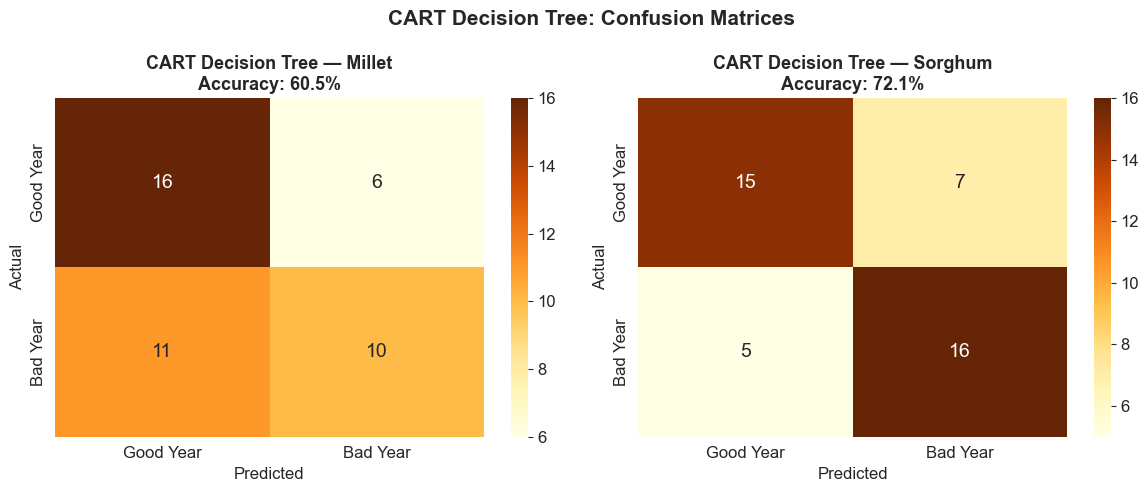


 CART Decision Tree done


In [23]:
# ── Classifier 5: CART Decision Tree ───────────────────
from sklearn.tree import DecisionTreeClassifier
print("📌 Classifier 5: CART Decision Tree")

cart_clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)

c9  = evaluate_classifier(cart_clf, X2, y_millet_cls,
                           'Millet',  'CART Decision Tree')
c10 = evaluate_classifier(cart_clf, X2, y_sorghum_cls,
                           'Sorghum', 'CART Decision Tree')
clf_results += [c9, c10]

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, result, crop in zip(axes, [c9, c10], ['Millet', 'Sorghum']):
    cm = confusion_matrix(result['y_true'], result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
                xticklabels=['Good Year', 'Bad Year'],
                yticklabels=['Good Year', 'Bad Year'],
                ax=ax, annot_kws={'size': 14})
    ax.set_title(
        f'CART Decision Tree — {crop}\n'
        f'Accuracy: {result["Accuracy"]*100:.1f}%',
        fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)

plt.suptitle('CART Decision Tree: Confusion Matrices',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n CART Decision Tree done")

# Classifier 6: CatBoost 

📌 Classifier 6: CatBoost

  CatBoost — Millet
  Accuracy: 0.5349 (53.5%)

              precision    recall  f1-score   support

   Good Year       0.54      0.59      0.57        22
    Bad Year       0.53      0.48      0.50        21

    accuracy                           0.53        43
   macro avg       0.53      0.53      0.53        43
weighted avg       0.53      0.53      0.53        43


  CatBoost — Sorghum
  Accuracy: 0.6744 (67.4%)

              precision    recall  f1-score   support

   Good Year       0.67      0.73      0.70        22
    Bad Year       0.68      0.62      0.65        21

    accuracy                           0.67        43
   macro avg       0.68      0.67      0.67        43
weighted avg       0.68      0.67      0.67        43



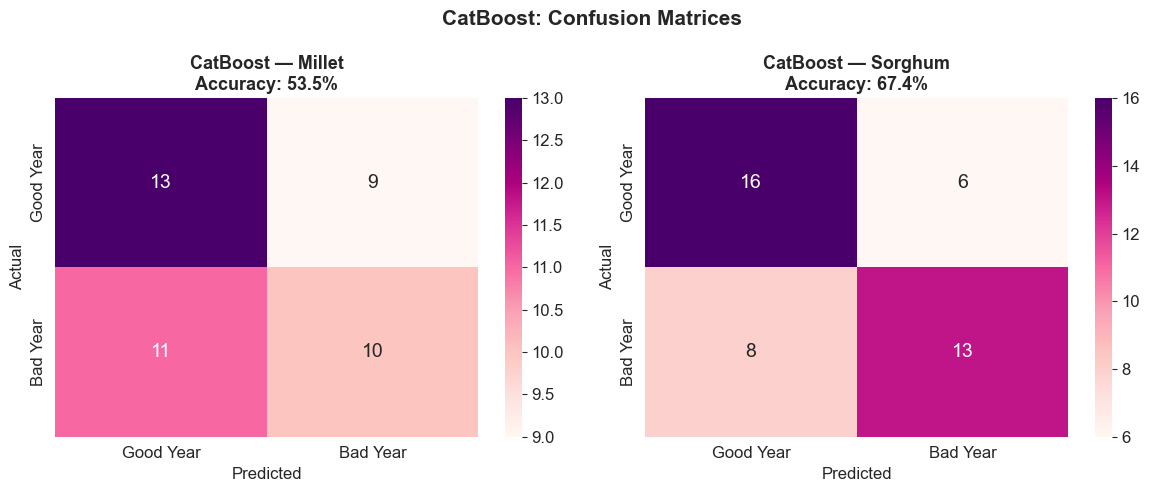


 CatBoost done


In [24]:
# ── Classifier 6: CatBoost ─────────────────────────────
from catboost import CatBoostClassifier
print("📌 Classifier 6: CatBoost")

cat_clf = CatBoostClassifier(
    iterations=100,
    depth=3,
    learning_rate=0.05,
    random_seed=42,
    verbose=False
)

c11 = evaluate_classifier(cat_clf, X2, y_millet_cls,
                           'Millet',  'CatBoost')
c12 = evaluate_classifier(cat_clf, X2, y_sorghum_cls,
                           'Sorghum', 'CatBoost')
clf_results += [c11, c12]

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, result, crop in zip(axes, [c11, c12], ['Millet', 'Sorghum']):
    cm = confusion_matrix(result['y_true'], result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
                xticklabels=['Good Year', 'Bad Year'],
                yticklabels=['Good Year', 'Bad Year'],
                ax=ax, annot_kws={'size': 14})
    ax.set_title(
        f'CatBoost — {crop}\n'
        f'Accuracy: {result["Accuracy"]*100:.1f}%',
        fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)

plt.suptitle('CatBoost: Confusion Matrices',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n CatBoost done")

# Classifier 7: KNN (Centroid Based)

📌 Classifier 7: KNN (Centroid-Based)

  KNN — Millet
  Accuracy: 0.5814 (58.1%)

              precision    recall  f1-score   support

   Good Year       0.59      0.59      0.59        22
    Bad Year       0.57      0.57      0.57        21

    accuracy                           0.58        43
   macro avg       0.58      0.58      0.58        43
weighted avg       0.58      0.58      0.58        43


  KNN — Sorghum
  Accuracy: 0.6047 (60.5%)

              precision    recall  f1-score   support

   Good Year       0.59      0.73      0.65        22
    Bad Year       0.62      0.48      0.54        21

    accuracy                           0.60        43
   macro avg       0.61      0.60      0.60        43
weighted avg       0.61      0.60      0.60        43



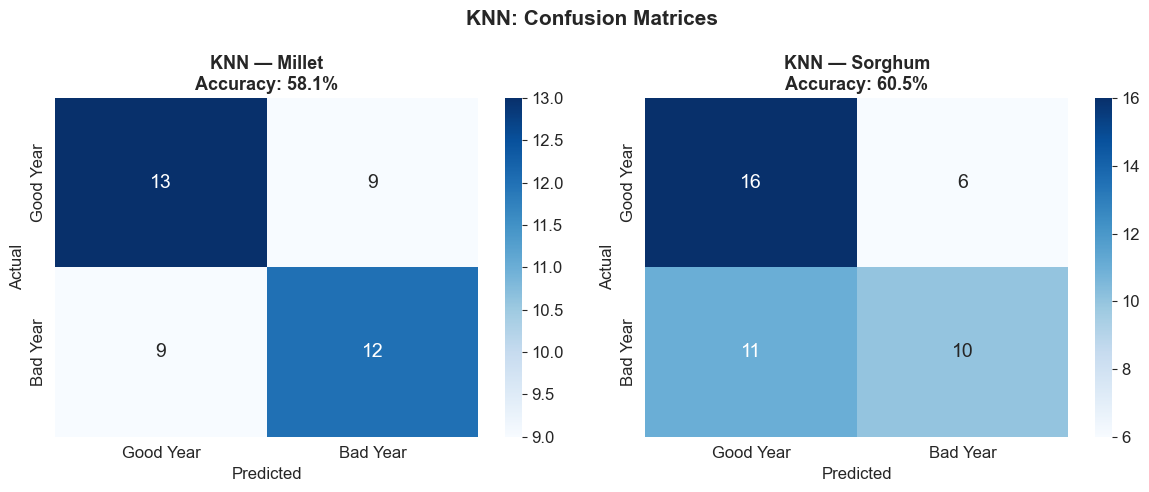


 KNN done


In [25]:
# ── Classifier 7: KNN ──────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
print("📌 Classifier 7: KNN (Centroid-Based)")

# KNN needs scaled features
knn_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(
        n_neighbors=5,
        metric='euclidean',
        weights='distance'
    ))
])

c13 = evaluate_classifier(knn_clf, X2, y_millet_cls,
                           'Millet',  'KNN')
c14 = evaluate_classifier(knn_clf, X2, y_sorghum_cls,
                           'Sorghum', 'KNN')
clf_results += [c13, c14]

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, result, crop in zip(axes, [c13, c14], ['Millet', 'Sorghum']):
    cm = confusion_matrix(result['y_true'], result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Good Year', 'Bad Year'],
                yticklabels=['Good Year', 'Bad Year'],
                ax=ax, annot_kws={'size': 14})
    ax.set_title(
        f'KNN — {crop}\n'
        f'Accuracy: {result["Accuracy"]*100:.1f}%',
        fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)

plt.suptitle('KNN: Confusion Matrices',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n KNN done")

# Final Model Comparison All 7 Models

📊 FINAL MODEL COMPARISON — ALL 7 CLASSIFIERS

📌 Millet — Bad Year Early Warning:
   Model                       Accuracy
   --------------------------------------
   Logistic Regression            62.8% ✅ BEST
   XGBoost                        60.5%
   CART Decision Tree             60.5%
   Random Forest                  58.1%
   KNN                            58.1%
   Gradient Boosting              55.8%
   CatBoost                       53.5%

📌 Sorghum — Bad Year Early Warning:
   Model                       Accuracy
   --------------------------------------
   XGBoost                        72.1% ✅ BEST
   CART Decision Tree             72.1% ✅ BEST
   Random Forest                  67.4%
   CatBoost                       67.4%
   Gradient Boosting              65.1%
   Logistic Regression            60.5%
   KNN                            60.5%


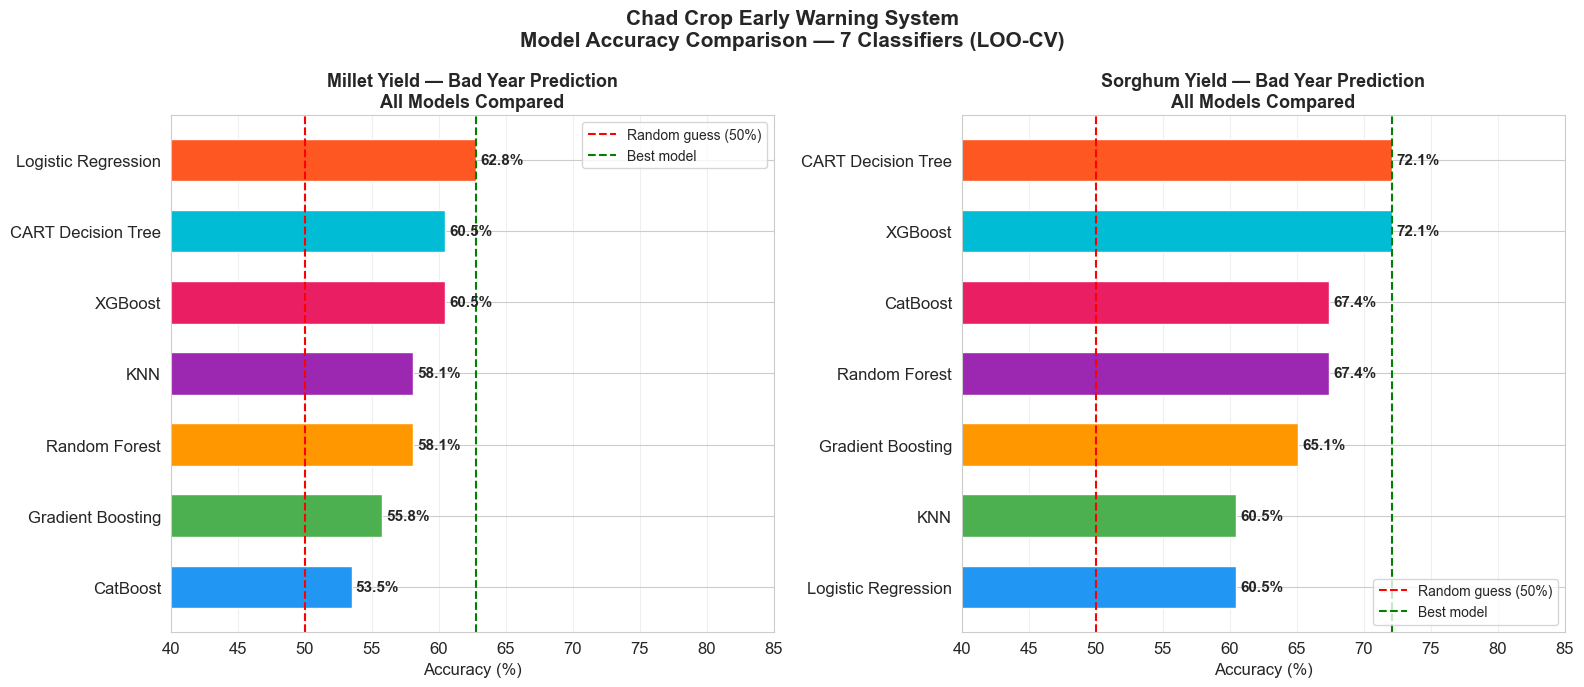


🏆 WINNERS:
   Millet: Logistic Regression — 62.8%
   Sorghum: XGBoost — 72.1%


In [26]:
# ── Final Comparison — All 7 Models ────────────────────
print("📊 FINAL MODEL COMPARISON — ALL 7 CLASSIFIERS")
print("="*60)

# Build comparison dataframe
comparison = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'y_pred' and k != 'y_true'}
    for r in clf_results
])
comparison['Accuracy_Pct'] = (comparison['Accuracy'] * 100).round(1)

# Print summary table
for crop in ['Millet', 'Sorghum']:
    print(f"\n📌 {crop} — Bad Year Early Warning:")
    print(f"   {'Model':<25} {'Accuracy':>10}")
    print(f"   {'-'*38}")
    subset = comparison[comparison['crop'] == crop].sort_values(
        'Accuracy_Pct', ascending=False)
    for _, row in subset.iterrows():
        best = " ✅ BEST" if row['Accuracy_Pct'] == subset['Accuracy_Pct'].max() else ""
        print(f"   {row['model']:<25} {row['Accuracy_Pct']:>9.1f}%{best}")

# Bar chart — side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0',
          '#E91E63', '#00BCD4', '#FF5722']

for ax, crop in zip(axes, ['Millet', 'Sorghum']):
    subset = comparison[comparison['crop'] == crop].sort_values(
        'Accuracy_Pct', ascending=True)
    bars = ax.barh(subset['model'], subset['Accuracy_Pct'],
                   color=colors, edgecolor='white', height=0.6)
    ax.axvline(50, color='red', linestyle='--',
               linewidth=1.5, label='Random guess (50%)')
    ax.axvline(subset['Accuracy_Pct'].max(), color='green',
               linestyle='--', linewidth=1.5, label='Best model')
    ax.set_xlim(40, 85)
    ax.set_title(f'{crop} Yield — Bad Year Prediction\nAll Models Compared',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Accuracy (%)', fontsize=12)
    for bar, val in zip(bars, subset['Accuracy_Pct']):
        ax.text(bar.get_width() + 0.3,
                bar.get_y() + bar.get_height()/2,
                f'{val}%', va='center', 
                fontsize=11, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle(
    'Chad Crop Early Warning System\n'
    'Model Accuracy Comparison — 7 Classifiers (LOO-CV)',
    fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Winner summary
print("\n🏆 WINNERS:")
for crop in ['Millet', 'Sorghum']:
    subset = comparison[comparison['crop'] == crop]
    best = subset.loc[subset['Accuracy_Pct'].idxmax()]
    print(f"   {crop}: {best['model']} — {best['Accuracy_Pct']}%")

# Feature Importance

📌 Feature Importance Analysis


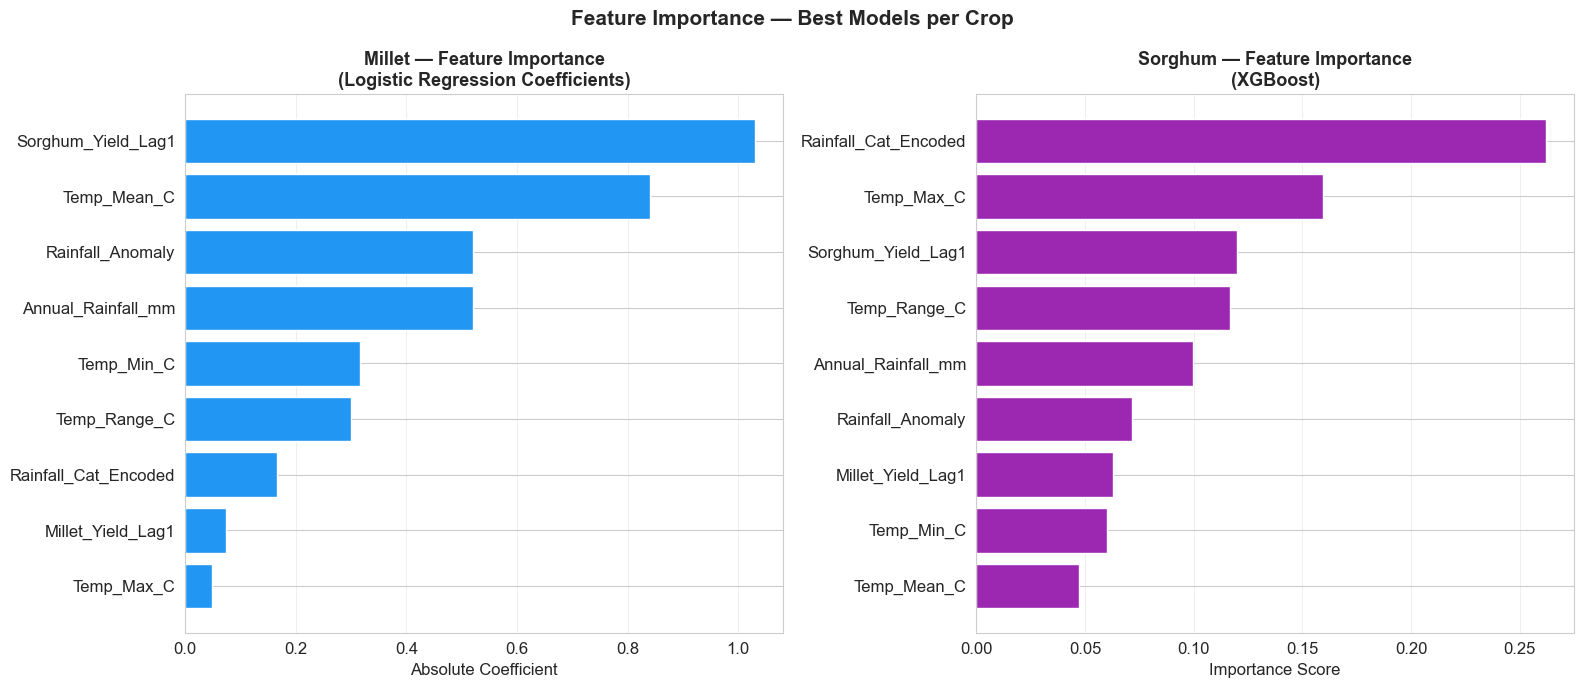


🔑 TOP 3 FEATURES:

   Millet (Logistic Regression):
   → Sorghum_Yield_Lag1        1.0295
   → Temp_Mean_C               0.8397
   → Rainfall_Anomaly          0.5197

   Sorghum (XGBoost):
   → Rainfall_Cat_Encoded      0.2619
   → Temp_Max_C                0.1595
   → Sorghum_Yield_Lag1        0.1199


In [27]:
# ── Feature Importance — Best Models ───────────────────
print("📌 Feature Importance Analysis")

# Train best models on full data
# Millet  → Logistic Regression (need coefficients)
# Sorghum → XGBoost (feature importance)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Millet: Logistic Regression coefficients ───────────
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)

lr_full = LogisticRegression(max_iter=1000)
lr_full.fit(X2_scaled, y_millet_cls)

coef_df = pd.DataFrame({
    'Feature'    : feature_cols_v2,
    'Importance' : np.abs(lr_full.coef_[0])
}).sort_values('Importance', ascending=True)

axes[0].barh(coef_df['Feature'], coef_df['Importance'],
             color='#2196F3', edgecolor='white')
axes[0].set_title(
    'Millet — Feature Importance\n(Logistic Regression Coefficients)',
    fontsize=13, fontweight='bold')
axes[0].set_xlabel('Absolute Coefficient', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='x')

# ── Sorghum: XGBoost feature importance ────────────────
xgb_full = XGBClassifier(
    n_estimators=100, max_depth=3,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, random_state=42,
    verbosity=0, eval_metric='logloss'
)
xgb_full.fit(X2, y_sorghum_cls)

imp_df = pd.DataFrame({
    'Feature'    : feature_cols_v2,
    'Importance' : xgb_full.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(imp_df['Feature'], imp_df['Importance'],
             color='#9C27B0', edgecolor='white')
axes[1].set_title(
    'Sorghum — Feature Importance\n(XGBoost)',
    fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle(
    'Feature Importance — Best Models per Crop',
    fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top 3 features per crop
print("\n🔑 TOP 3 FEATURES:")
print(f"\n   Millet (Logistic Regression):")
for _, row in coef_df.tail(3).iloc[::-1].iterrows():
    print(f"   → {row['Feature']:<25} {row['Importance']:.4f}")

print(f"\n   Sorghum (XGBoost):")
for _, row in imp_df.tail(3).iloc[::-1].iterrows():
    print(f"   → {row['Feature']:<25} {row['Importance']:.4f}")

Millet:

Last year's sorghum yield is the strongest predictor — when sorghum fails, millet follows the next year. Cascading crop failure pattern.
Mean temperature matters more than rainfall for millet
Rainfall anomaly confirms it's deviation from normal that matters, not absolute rainfall

Sorghum:

Rainfall category (Drought/Below Normal/Normal/Good) is the top predictor
Maximum temperature — heat stress directly impacts sorghum
Last year's sorghum yield — momentum effect, good years tend to follow good years

# Project Summary

In [28]:
# ── Final Project Summary ───────────────────────────────
print("="*65)
print(" CHAD CROP YIELD EARLY WARNING SYSTEM")
print(" Project Summary")
print("="*65)

print("""
 DATA SOURCES:
   • FAO FAOSTAT  — Millet & Sorghum yields, Chad 1981–2024
   • NASA POWER   — Rainfall, Temperature (Mean/Max/Min), Chad

 DATASET:
   • 43 years of data (1982–2024 after lag feature creation)
   • 9 features including engineered lag & anomaly variables
   • Balanced classes: 21 bad years / 22 good years per crop

 KEY FINDINGS:
   1. Rainfall alone is a WEAK predictor of crop failure
      (bad years avg 548mm vs overall avg 557mm)
   2. 65% of years in Chad have below-average rainfall —
      drought is the default condition, not the exception
   3. Last year's yield is the strongest predictor for both
      crops — cascading failures are a real pattern
   4. Millet is more temperature-sensitive than sorghum
   5. Sorghum responds more to rainfall category than
      absolute rainfall amount

 MODEL RESULTS:
   • Millet  → Logistic Regression : 62.8% accuracy
   • Sorghum → XGBoost             : 72.1% accuracy
   • Baseline (random guess)       : 50.0%
   • All models evaluated with Leave-One-Out Cross Validation

 EARLY WARNING THRESHOLDS:
   • Millet  bad year : yield < 517 kg/ha
   • Sorghum bad year : yield < 703 kg/ha

 POLICY IMPLICATIONS:
   → WFP/FAO can use this model to pre-position food aid
   → Monitor temperature anomalies alongside rainfall
   → Consecutive bad years signal compounding food crisis
   → Sorghum is more predictable — prioritize for planning
""")
print("="*65)
print(" github.com/Derio001/chad-crop-yield-prediction")
print("="*65)

 CHAD CROP YIELD EARLY WARNING SYSTEM
 Project Summary

 DATA SOURCES:
   • FAO FAOSTAT  — Millet & Sorghum yields, Chad 1981–2024
   • NASA POWER   — Rainfall, Temperature (Mean/Max/Min), Chad

 DATASET:
   • 43 years of data (1982–2024 after lag feature creation)
   • 9 features including engineered lag & anomaly variables
   • Balanced classes: 21 bad years / 22 good years per crop

 KEY FINDINGS:
   1. Rainfall alone is a WEAK predictor of crop failure
      (bad years avg 548mm vs overall avg 557mm)
   2. 65% of years in Chad have below-average rainfall —
      drought is the default condition, not the exception
   3. Last year's yield is the strongest predictor for both
      crops — cascading failures are a real pattern
   4. Millet is more temperature-sensitive than sorghum
   5. Sorghum responds more to rainfall category than
      absolute rainfall amount

 MODEL RESULTS:
   • Millet  → Logistic Regression : 62.8% accuracy
   • Sorghum → XGBoost             : 72.1% accuracy
 

# Save Final Dataset

In [29]:
# ── Save cleaned datasets ───────────────────────────────
df_model.to_csv('chad_crop_climate_merged.csv', index=False)

# Save model comparison
comparison.to_csv('model_comparison_results.csv', index=False)

print("✅ Files saved:")
print(f"   • chad_crop_climate_merged.csv  — {len(df_model)} rows, {len(df_model.columns)} columns")
print(f"   • model_comparison_results.csv — model benchmarking results")
print(f"\nDataset columns:")
for col in df_model.columns:
    print(f"   • {col}")

✅ Files saved:
   • chad_crop_climate_merged.csv  — 43 rows, 19 columns
   • model_comparison_results.csv — model benchmarking results

Dataset columns:
   • Year
   • Millet_Area_harvested
   • Millet_Production
   • Millet_Yield
   • Sorghum_Area_harvested
   • Sorghum_Production
   • Sorghum_Yield
   • Annual_Rainfall_mm
   • Temp_Mean_C
   • Temp_Max_C
   • Temp_Min_C
   • Millet_Yield_Lag1
   • Sorghum_Yield_Lag1
   • Rainfall_Category
   • Temp_Range_C
   • Rainfall_Anomaly
   • Rainfall_Cat_Encoded
   • Millet_BadYear
   • Sorghum_BadYear


## ✅ Project Complete

### What We Built
A **crop yield early warning system** for Chad using 43 years 
of FAO + NASA climate data. The system predicts whether a 
given year will be a **bad harvest year** for millet and 
sorghum — giving NGOs and governments advance warning to 
pre-position food aid.

### Best Models
| Crop | Best Model | Accuracy |
|------|-----------|----------|
| Millet | Logistic Regression | 62.8% |
| Sorghum | XGBoost | 72.1% |

### Key Insight
**Rainfall alone cannot predict crop failure in Chad.**  
Last year's yield + temperature anomalies are stronger 
signals than annual precipitation — a finding with direct 
implications for how WFP and FAO design early warning systems.

### Data Sources
- [FAO FAOSTAT](https://www.fao.org/faostat)
- [NASA POWER](https://power.larc.nasa.gov/)

### Author
Mahamat Hanga Derio — Christ University, Bangalore  
github.com/Derio001